# 6.7 杠杆与保证金管理 (Leverage & Margin)

## 学习目标
- 理解杠杆如何同时放大收益和风险
- 分析不同杠杆倍数下的资金曲线差异
- 计算融资成本（Margin Interest）对净收益的影响
- 用最优杠杆公式找到最优区间


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
print('Libraries loaded')


Libraries loaded


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. 杠杆的双刃剑效应

**杠杆 (Leverage)** 指你实际控制的资产价值与你的自有资本之比：

$$\text{杠杆倍数} = \frac{\text{持仓市值}}{\text{净资产}}$$

- 2 倍杠杆意味着：借入等额资金，实际持仓是净资产的 2 倍
- 如果股票涨 5%，你赚 **10%（2 倍）**
- 如果股票跌 5%，你亏 **10%（2 倍）** 或 **更多**（加上融资利率）


1.0x 杠杆: 3年总收益=7.84%, 最大回撤=-19.52%
1.5x 杠杆: 3年总收益=2.90%, 最大回撤=-30.41%
2.0x 杠杆: 3年总收益=-3.42%, 最大回撤=-40.27%
3.0x 杠杆: 3年总收益=-19.01%, 最大回撤=-56.98%
4.0x 杠杆: 3年总收益=-36.41%, 最大回撤=-69.93%


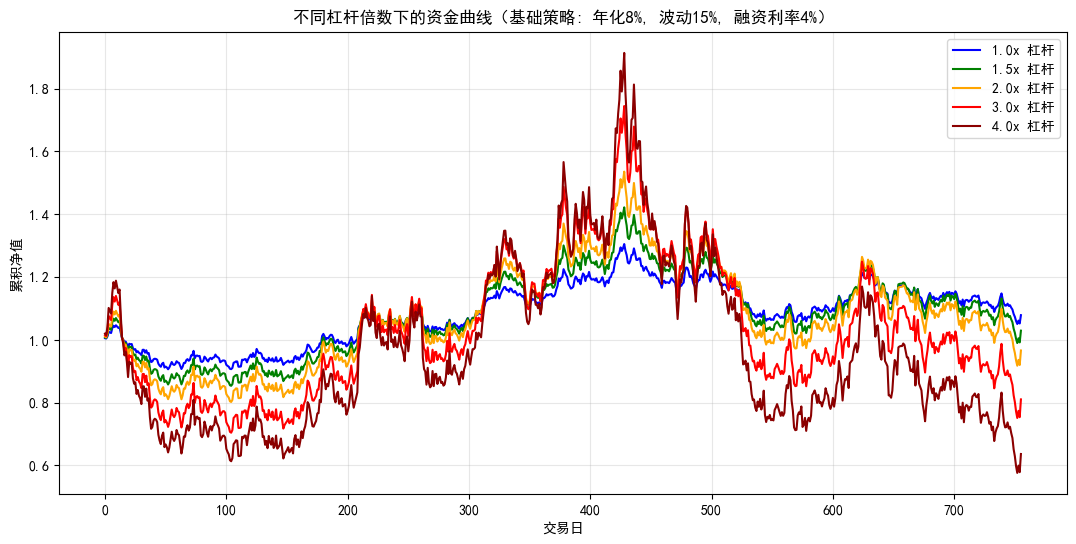

In [4]:
# 模拟不同杠杆倍数下的资金曲线
np.random.seed(42)
n_days = 252 * 3  # 3 年

# 基础策略：年化 8%，波动 15%
base_returns = np.random.normal(0.08/252, 0.15/np.sqrt(252), n_days)

# 融资利率（年化）
margin_rate = 0.04  # 年化 4%
daily_margin_cost = margin_rate / 252

leverage_ratios = [1.0, 1.5, 2.0, 3.0, 4.0]
colors = ['blue', 'green', 'orange', 'red', 'darkred']

plt.figure(figsize=(13, 6))

for lev, color in zip(leverage_ratios, colors):
    # 杠杆后收益 = 原始收益 * 杠杆倍数 - 融资成本 * (杠杆-1)
    leveraged_returns = lev * base_returns - (lev - 1) * daily_margin_cost
    cumulative = (1 + leveraged_returns).cumprod()
    plt.plot(cumulative, color=color, linewidth=1.5, label=f'{lev}x 杠杆')
    final = cumulative[-1]

    max_dd = (cumulative / np.maximum.accumulate(cumulative) - 1).min()
    print(f'{lev}x 杠杆: 3年总收益={final-1:.2%}, 最大回撤={max_dd:.2%}')

plt.title(f'不同杠杆倍数下的资金曲线（基础策略: 年化8%, 波动15%, 融资利率4%）')
plt.xlabel('交易日')
plt.ylabel('累积净值')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 2. 最优杠杆：Merton 分数

对于给定的预期收益和波动率，存在一个数学意义上的最优杠杆倍数：

$$L^* = \frac{\mu - r}{\sigma^2}$$

其中 $\mu$ 是策略年化预期收益，$r$ 是融资利率，$\sigma$ 是年化波动率。

> 注意：这与 Kelly Criterion 在连续时间假设下是等价的！


最优杠杆倍数（Merton Division）: 1.78x
Half-Merton（实盘常用）: 0.89x


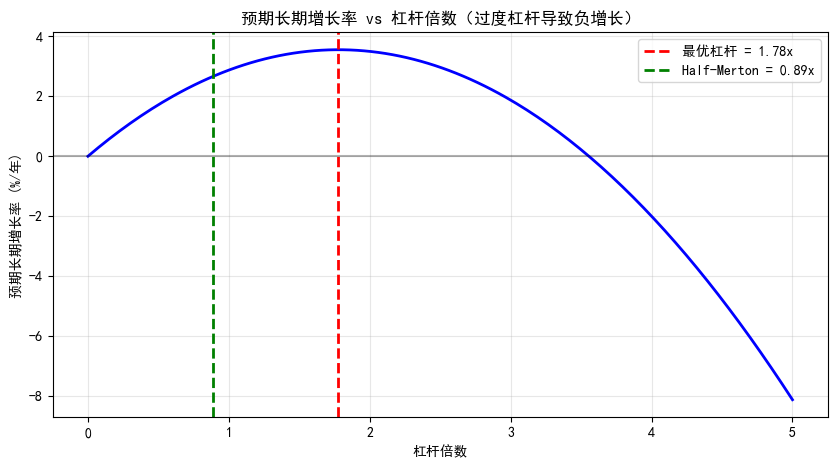

In [5]:
annual_mu = 0.08    # 策略年化预期收益 8%
annual_r  = 0.04    # 融资利率 4%
annual_sigma = 0.15  # 波动率 15%

optimal_leverage = (annual_mu - annual_r) / (annual_sigma ** 2)
print(f'最优杠杆倍数（Merton Division）: {optimal_leverage:.2f}x')
print(f'Half-Merton（实盘常用）: {optimal_leverage/2:.2f}x')

# 可视化：杠杆 vs 预期长期增长率
leverage_range = np.linspace(0, 5, 200)
# 长期增长率 = (μ-r) * L - 0.5 * σ² * L²
long_run_growth = (annual_mu - annual_r) * leverage_range - 0.5 * annual_sigma**2 * leverage_range**2

plt.figure(figsize=(10, 5))
plt.plot(leverage_range, long_run_growth * 100, color='blue', linewidth=2)
plt.axvline(optimal_leverage, color='red', linestyle='--', linewidth=2,
            label=f'最优杠杆 = {optimal_leverage:.2f}x')
plt.axvline(optimal_leverage/2, color='green', linestyle='--', linewidth=2,
            label=f'Half-Merton = {optimal_leverage/2:.2f}x')
plt.axhline(0, color='black', alpha=0.3)
plt.xlabel('杠杆倍数')
plt.ylabel('预期长期增长率 (%/年)')
plt.title('预期长期增长率 vs 杠杆倍数（过度杠杆导致负增长）')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 3. 爆仓风险分析

使用过高杠杆时，即使是短暂的市场下跌也可能导致净资产清零（爆仓）。
保证金水平通常要求净资产保持在持仓价值的一定比例以上。


1.0x 杠杆: 0/500 次模拟爆仓 (0.0%)
2.0x 杠杆: 21/500 次模拟爆仓 (4.2%)
3.0x 杠杆: 214/500 次模拟爆仓 (42.8%)
4.0x 杠杆: 393/500 次模拟爆仓 (78.6%)
5.0x 杠杆: 487/500 次模拟爆仓 (97.4%)


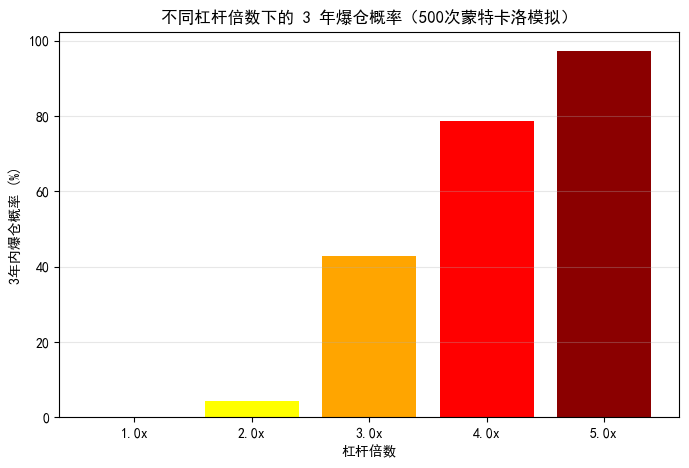

In [6]:
# 模拟爆仓风险场景
margin_call_threshold = 0.2  # 净资产跌到 20% 以下触发爆仓
np.random.seed(123)

bankruptcy_counts = {}
for lev in [1.0, 2.0, 3.0, 4.0, 5.0]:
    bankrupt = 0
    for trial in range(500):
        equity = 1.0  # 起始净资产归一化为 1
        for _ in range(252 * 3):
            r = np.random.normal(0.08/252, 0.15/np.sqrt(252))
            equity = equity + lev * equity * r - (lev - 1) * equity * daily_margin_cost
            if equity / lev < margin_call_threshold:  # 爆仓条件
                bankrupt += 1
                break
    bankruptcy_counts[lev] = bankrupt / 500
    print(f'{lev}x 杠杆: {bankrupt}/500 次模拟爆仓 ({bankrupt/500:.1%})')

# 可视化爆仓概率
plt.figure(figsize=(8, 5))
plt.bar([str(k)+'x' for k in bankruptcy_counts], [v*100 for v in bankruptcy_counts.values()],
        color=['green', 'yellow', 'orange', 'red', 'darkred'])
plt.xlabel('杠杆倍数')
plt.ylabel('3年内爆仓概率 (%)')
plt.title('不同杠杆倍数下的 3 年爆仓概率（500次蒙特卡洛模拟）')
plt.grid(alpha=0.3, axis='y')
plt.show()


## 🎯 练习

1. 将基础策略修改为夏普比率 = 0.5（如年化 8%，波动 16%），重新计算最优杠杆。结果如何变化？
2. 对当前的 Beta 对冲组合（市场中性，年化 5%，波动 5%），计算其理论最优杠杆。
3. 模拟一个每月动态调整杠杆的框架（当近期夏普下降时降低杠杆），观察爆仓概率如何变化。

---
**下一节** → `../README.md（教程完结，恭喜！）`
